In [1]:
#| output: false
#| echo: false
%cd ..

C:\Users\Logan\WorkGits\isw-modflow


### Introduction

This document compares coupled analytical models of streamflow depletion and aquifer drawdown implemented in the [*isw*](https://gopalpenny.github.io/isw/) package to a numerical simulation in MODFLOW 6. 

The isw package implements two approaches (ADF and constant head) for estimating stream depletion and aquifer drawdown. Both use the same pair of analytical solutions: the @theis-1935 solution for radial drawdown from a pumping well in a confined aquifer and the @glover-1954 solution for streamflow depletion along a fully penetrating stream with no streambed resistance. 

- ADF approach estimates streamflow depletion at each stream segment and then scales each segment’s depletion by a distance-based weighting fraction (e.g., via Web or Web Squared apportionment schemes). Total streamflow depletion is calculated as the sum of the weighted, segment-based depletion estimates. Those weighted, segment-based depletion estimates are then used as image-well injection rates. Net water-level change at an observation well is calculated by subtracting pumping-well drawdown from stream recovery.
- Constant head approach instead treats each stream segment as a constant head boundary, and solves for the image-well injection rates needed to drive net water-level change to zero at points along each stream segment. Total streamflow depletion and net water-level change calculations remain the same. 

We use the example problem included with the isw package for the comparison. The problem includes two pumping wells, a nearby stream network consisting of three connected reaches, and two monitoring wells at near and downstream locations (@fig-map). Pumping schedules and aquifer hydraulic properties differ between the two pumping wells (@tbl-schedule; @tbl-parameters). 

In [2]:
from pathlib import Path
import math

import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import box

from scipy.special import exp1
from scipy.optimize import brentq

import flopy
from flopy.utils import HeadFile, CellBudgetFile
from flopy.utils.gridgen import Gridgen

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, MultipleLocator
from matplotlib.colors import Normalize, TwoSlopeNorm, ListedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable

plt.rcParams["font.family"] = "Arial"
mm = 1/25.4  # mm to inches

def theis(Q, T, S, r, t):
    """Computues Theis aquifer drawdown."""
    u = (r**2*S) / (4*T*t)
    return Q/(4*math.pi*T) * exp1(u)

def estimate_roi(Q, T, S, t, tolerance=0.001):
    """Computes the radius at which Theis drawdown drops below tolerance under constant pumping rate."""
    return brentq(lambda r: theis(Q, T, S, r, t) - tolerance, 1.0, 1e6)

def read_heads(ws: Path,
               name: str) -> np.ndarray:
    """Reads heads.
    """
    hds = HeadFile(ws/f"{name}.hds")
    heads = []
    for t in hds.get_times():
        heads.append(hds.get_data(totim=t))
    heads = np.stack(heads)
    return heads

def read_budget(ws: Path,
                name: str,
                nlay: int,
                ncpl: int) -> dict[str, np.ndarray]:
    """Reads cell-by-cell budget.
    """
    terms = ["CHD", "WEL", "STO-SS"]
    cbc = CellBudgetFile(ws/f"{name}.cbc")
    budget = {term: [] for term in terms}
    for t in cbc.get_times():
        for term in terms:
            # handle storage terms for both steady-state & transient cases
            try:
                q = cbc.get_data(totim=t, text=term, full3D=True)[0]
            except Exception: 
                q = np.zeros((nlay, 1, ncpl), dtype=float)
            budget[term].append(q)
    for term in terms:
        budget[term] = np.stack(budget[term], axis=0)
    return budget

def compute_budget(budget: dict[str, np.ndarray], 
                   times: list) -> pd.DataFrame:
    """Computes net inflows and outflows using the cell-by-cell budget.
    """
    chd = budget["CHD"]
    wel = budget["WEL"]
    storage = budget["STO-SS"]

    chd_net = chd.sum(axis=(1,2,3))
    wel_net = wel.sum(axis=(1,2,3))
    storage_net = storage.sum(axis=(1,2,3))
    total_net = chd_net + wel_net + storage_net

    total_in = sum(np.where(q > 0, q, 0).sum(axis=(1,2,3)) for q in (chd, wel, storage))
    total_out = sum(np.where(q < 0, q, 0).sum(axis=(1,2,3)) for q in (chd, wel, storage))
    percent_discrepancy = np.round(100 * (total_in + total_out) / ((total_in - total_out) / 2), 2)

    budget = pd.DataFrame({
        "time":          times,
        "constant_head": chd_net,
        "wells":         wel_net,
        "storage":       storage_net,
        "total":         total_net,
        "percent_discrepancy":  percent_discrepancy
    })
    return budget

In [3]:
streams = gpd.read_file(Path("data", "isw-vignette.gpkg"), layer="streams")
pumping_wells = gpd.read_file(Path("data", "isw-vignette.gpkg"), layer="pumping_wells")
observation_wells = gpd.read_file(Path("data", "isw-vignette.gpkg"), layer="observation_wells")

pumping_wells["pump_id"] = pd.Categorical(pumping_wells["pump_id"], categories=["pump_1", "pump_2"], ordered=True)
observation_wells["observation_id"] = pd.Categorical(observation_wells["observation_id"], categories=["obs_near", "obs_downstream"], ordered=True)

pumping_schedules = pd.DataFrame({
    "t": pd.to_datetime(["2025-01-01", "2025-02-01", "2025-03-01", "2025-04-01"]),
    "pump_1": [500, 500, 300, 0],
    "pump_2": [0, 250, 250, 0]
})
pumping_schedules["t"] = (pumping_schedules["t"] - pumping_schedules["t"].min()).dt.days

print(f"Total stream network length: {streams.length.sum()/1000:,.2f} km")
print(f"Number of pumping wells: {len(pumping_wells)}")
print(f"Number of monitoring wells: {len(observation_wells)}")

Total stream network length: 2.55 km
Number of pumping wells: 2
Number of monitoring wells: 2


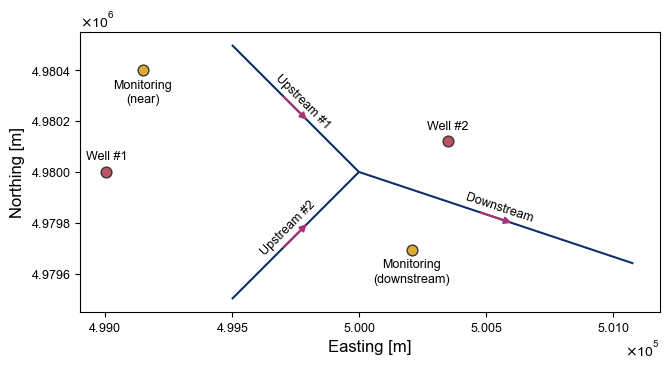

In [4]:
#| code-fold: true
#| label: fig-map
#| fig-cap: "Map of example problem showing the two pumping wells, two monitoring wells, and stream network."

fig, ax = plt.subplots(figsize=(190*mm, 190*mm))
streams.plot(ax=ax, color="#08306B", zorder=0)
pumping_wells.plot(ax=ax, color="#BB5566", edgecolor="#373737", markersize=60, zorder=1)
observation_wells.plot(ax=ax, color="#DDAA33", edgecolor="#373737", markersize=60, zorder=1)
for (idx, row), label in zip(pumping_wells.iterrows(), ["Well #1", "Well #2"]):
    ax.annotate(text=label,
                xy=(row.geometry.x, row.geometry.y),
                xytext=(row.geometry.x, row.geometry.y+35),
                ha="center", va="bottom", fontsize=9, color="#000000", zorder=2)
for (idx, row), label in zip(observation_wells.iterrows(), ["Monitoring\n(near)", "Monitoring\n(downstream)"]):
    ax.annotate(text=label,
                xy=(row.geometry.x, row.geometry.y),
                xytext=(row.geometry.x, row.geometry.y-35),
                ha="center", va="top", fontsize=9, color="#000000", zorder=2)
for (idx, row), label in zip(streams.iterrows(), ["Upstream #1", "Upstream #2", "Downstream"]):
    coords = np.array(row.geometry.coords)
    p0, p1 = coords[0], coords[-1]
    mid = (p0 + p1) / 2
    direction = (p1 - p0) / np.linalg.norm(p1 - p0)
    start = mid - direction * 75
    end   = mid + direction * 75
    ax.annotate("", xy=end, xytext=start, arrowprops=dict(arrowstyle="-|>", color="#AA3377", lw=1.5), zorder=3)
    pos = np.array([-direction[1], direction[0]])
    pos = mid + pos * 40
    angle = np.degrees(np.arctan2(direction[1], direction[0]))
    if angle > 90 or angle < -90:
        angle += 180 
    ax.text(pos[0], pos[1], label, rotation=angle, rotation_mode="anchor", ha="center", va="center", fontsize=9, color="#000000", zorder=3)    
ax.set_xlabel("Easting [m]", fontsize=12)
ax.set_ylabel("Northing [m]", fontsize=12)
ax.tick_params(labelsize=9)
ax.ticklabel_format(axis="both", style="sci", scilimits=(0, 0), useMathText=True, useOffset=False)
ax.set_aspect("equal")
plt.show()

In [5]:
#| label: tbl-schedule
#| tbl-cap: "Pumping schedules for the two pumping wells."
#| echo: false

table = pumping_schedules.copy()
table = table.set_index("t")
table = table.style.format("{:.0f}")
table = table.relabel_index(["Well #1 (m³/d)", "Well #2 (m³/d)"], axis=1)
table

,Well #1 (m³/d),Well #2 (m³/d)
t,,
0,500,0
31,500,250
59,300,250
90,0,0


In [6]:
#| label: tbl-parameters
#| tbl-cap: "Aquifer hydraulic parameters associated with each pumping well."
#| echo: false

table = pumping_wells.copy()
table.index = [f"Well #{i+1}" for i in range(len(table))]
table.drop(columns="pump_id", inplace=True)
table = table[["K", "V", "D", "well_diam"]]
table.rename(columns={"K": "K (m/s)", 
                      "V": "S (-)",
                      "D": "Aquifer thickness (m)",
                      "well_diam": "Well diameter (m)"}, 
             inplace=True)
table.style.format({"k (m/s)": "{:.2e}",
                    "Aquifer thickness (m)": "{:.0f}",
                    "S (-)": "{:.2f}",
                    "Well diameter (m)": "{:.2f}"})

,K (m/s),S (-),Aquifer thickness (m),Well diameter (m)
Well #1,0.000020,0.10,110,0.30
Well #2,0.000012,0.12,90,0.30


### Methods

isw’s methods for estimating streamflow depletion and aquifer drawdown are compared against a numerical MODFLOW simulation. Only the impact of a single pumping well on stream depletion and aquifer drawdown is considered. The example problem is represented in MODFLOW 6, and aligned to the assumptions of the two isw approaches to the extent possible. Below are some of the main implementation details:

- Daily timesteps, monthly stress periods
- Quadtree mesh with 12.5-200 m cells, allowing local refinement between pumping wells, monitoring wells, and the stream network; built using USGS’s gridgen program
- Simulated as confined, i.e., constant transmissivity, to match the assumptions of Theis and Glover-Balmer solutions.
- Spatially-uniform $K$ and $S_{s}$
- Pumping well is represented with same pumping schedule
- Stream network is represented as constant head boundary condition, same zero-drawdown assumption used by isw’s constant-head approach

In [7]:
# Select pumping well near monitoring well
ID = "pump_1"
pumping_wells     = pumping_wells[pumping_wells["pump_id"] == ID]
pumping_schedules = pumping_schedules[["t", ID]]

t = 365.0                              # time (d)
k = float(pumping_wells["K"])*86400.0  # hydraulic conductivity (m/d)
b = float(pumping_wells["D"])          # aquifer thickness (m)
s = float(pumping_wells["V"])          # storativity (-)
ss = s / b                             # specific storage (1/m)

C:\Users\Logan\AppData\Local\Temp\ipykernel_9608\3500624516.py:7: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  k = float(pumping_wells["K"])*86400.0  # hydraulic conductivity (m/d)
C:\Users\Logan\AppData\Local\Temp\ipykernel_9608\3500624516.py:8: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  b = float(pumping_wells["D"])          # aquifer thickness (m)
C:\Users\Logan\AppData\Local\Temp\ipykernel_9608\3500624516.py:9: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  s = float(pumping_wells["V"])          # storativity (-)


In [8]:
# Estimate the radius of influence using theis solution to determine quadtree mesh extent
roi = estimate_roi(Q=500.0, T=k*b, S=s, t=365.0)
roi = math.ceil(roi/5)*5 
print(f"Radius of influence where drawdown drops below 1 mm using Theis = {estimate_roi(Q=500.0, T=k*b, S=s, t=365.0):.1f} m at {t} d") 

xmin = min(streams.total_bounds[0], pumping_wells.total_bounds[0], observation_wells.total_bounds[0])
ymin = min(streams.total_bounds[1], pumping_wells.total_bounds[1], observation_wells.total_bounds[1])
xmax = max(streams.total_bounds[2], pumping_wells.total_bounds[2], observation_wells.total_bounds[2])
ymax = max(streams.total_bounds[3], pumping_wells.total_bounds[3], observation_wells.total_bounds[3])
extent = (xmin, ymin, xmax, ymax)

x = xmax-xmin
y = ymax-ymin

print(f"Map easting:  {xmin} - {xmax} (m)")
print(f"Map northing: {ymin} - {ymax} (m)")

print(f"Map x:  {x} (m)")
print(f"Map y:  {y} (m)")

xmin = xmin - roi; xmax = xmax + roi
ymin = ymin - roi; ymax = ymax + roi

print(f"Grid easting:  {xmin} - {xmax} (m)")
print(f"Grid northing: {ymin} - {ymax} (m)")

x = xmax-xmin
y = ymax-ymin

print(f"Grid x:  {x} (m)")
print(f"Grid y:  {y} (m)")

Radius of influence where drawdown drops below 1 mm using Theis = 3250.5 m at 365.0 d
Map easting:  499006.0 - 501080.0 (m)
Map northing: 4979500.0 - 4980500.0 (m)
Map x:  2074.0 (m)
Map y:  1000.0 (m)
Grid easting:  495751.0 - 504335.0 (m)
Grid northing: 4976245.0 - 4983755.0 (m)
Grid x:  8584.0 (m)
Grid y:  7510.0 (m)


In [9]:
# Construct MODFLOW model
mws = Path("models", "isw")
gws = Path("models", "isw", "grid")
mws.mkdir(exist_ok=True)
gws.mkdir(exist_ok=True)

# Build quadtree mesh using roi and extent around pumping wells, monitoring wells, and stream network
dx = dy = 200
nlay = 1
nrow = int(np.floor(y / dy))
ncol = int(np.floor(x / dx))
delc = np.full((nrow,), dx)
delr = np.full((ncol,), dy)
top = np.zeros((nrow, ncol))
botm = np.full((nlay, nrow, ncol), top - b)
idomain = np.ones((nlay, nrow, ncol), dtype=int)
grid = flopy.discretization.StructuredGrid(delc=delc, delr=delr, top=top, botm=botm, idomain=idomain, xoff=xmin, yoff=ymin, crs="EPSG:32615")
gridgen = Gridgen(grid, model_ws=gws, exe_name=Path("bin", "win64", "gridgen.exe"))

for level, distance in [(1, 0.80*roi), (2, 0.45*roi), (3, 0.20*roi), (4, 0.06*roi)]:
    refinement_zone = box(*extent).buffer(distance)
    gridgen.add_refinement_features([refinement_zone], "polygon", level, range(1))
    
gridgen.build(verbose=False)
gridprops = gridgen.get_gridprops_disv()
ncpl = int(gridprops["ncpl"])
dxy = np.unique(np.sqrt(gridgen.get_area()))
print(f"Number of model cells: {ncpl:,.0f}")
print(f"Cell size range: {dxy.min():.1f}-{dxy.max():.1f} m")

top = np.zeros(ncpl)
botm = np.full((nlay, ncpl), top - b)
idomain = np.ones((nlay, ncpl), dtype=int)
grid = flopy.discretization.VertexGrid(vertices=gridprops["vertices"], cell2d=gridprops["cell2d"], top=top, botm=botm, idomain=idomain, crs="EPSG:32615")
gridintersect = flopy.utils.GridIntersect(grid)

# Intersect pumping wells, monitoring wells, and stream network to mesh
observation_wells["icpl"] = None
for idx, geom in observation_wells.geometry.items():
    observation_wells.loc[idx, "icpl"] = int(gridintersect.intersect(geom).cellids[0])
observation_wells["icpl"] = observation_wells["icpl"].astype(int)
observation_wells = observation_wells[[c for c in observation_wells.columns if c != "geometry"] + ["geometry"]]

pumping_wells["icpl"] = None
for idx, geom in pumping_wells.geometry.items():
    pumping_wells.loc[idx, "icpl"] = int(gridintersect.intersect(geom).cellids[0])
pumping_wells["icpl"] = pumping_wells["icpl"].astype(int)
pumping_wells = pumping_wells[[c for c in pumping_wells.columns if c != "geometry"] + ["geometry"]]

streams["icpl"] = None
streams["length"] = None
streams["icpl"] = streams["icpl"].astype(object)
streams["length"] = streams["length"].astype(object)
for idx, geom in streams.geometry.items():
    ix = gridintersect.intersect(geom)
    streams.at[idx, "icpl"] = [int(c) for c in ix.cellids]
    streams.at[idx, "length"] = [float(l) for l in ix.lengths]
streams = streams[[c for c in streams.columns if c != "geometry"] + ["geometry"]]

# MODFLOW SIMULATION
sim = flopy.mf6.MFSimulation(sim_name="sim", sim_ws=mws, version="mf6", exe_name=Path("bin", "win64", "mf6.exe"))

# GROUNDWATER FLOW MODEL
gwf = flopy.mf6.ModflowGwf(sim, modelname="isw", save_flows=True)

# SOLVER (.ims package)
ims = flopy.mf6.ModflowIms(sim, complexity="MODERATE")

# TEMPORAL DISCRETIZATION (.tdis package)
perlen = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
nstp = perlen
tsmult = 1.0
times = list(range(1, sum(perlen)+1))
tdis = flopy.mf6.ModflowTdis(sim,
                             nper=len(perlen),
                             perioddata=list(zip(perlen, nstp, [tsmult] * len(perlen))),
                             time_units="days",
                             start_date_time="2025-01-01")

# SPATIAL DISCRETIZATION (.disv package) - quadtree mesh from gridgen
disv = flopy.mf6.ModflowGwfdisv(gwf,
                                nlay=nlay,
                                ncpl=ncpl,
                                nvert=gridprops["nvert"],
                                vertices=gridprops["vertices"],
                                cell2d=gridprops["cell2d"],
                                top=top,
                                botm=botm,
                                idomain=idomain,
                                length_units="m")
gwf.modelgrid.crs = "EPSG:32615"

# HYDRAULIC PROPERTIES (.npf package) 
npf = flopy.mf6.ModflowGwfnpf(gwf,
                              k=k,
                              icelltype=0,  # confined → constant transmissivity to match Theis & Glover's assumption
                              save_flows=True,
                              save_specific_discharge=True)

# STORAGE PROPERTIES (.sto package) 
sto = flopy.mf6.ModflowGwfsto(gwf,
                              ss=ss,
                              iconvert=0,  # confined → constant transmissivity to match Theis & Glover's assumption
                              transient={0: True},
                              save_flows=True) 

# INITIAL CONDITIONS (.ic package)
ic = flopy.mf6.ModflowGwfic(gwf, strt=0.0)

# PUMPING WELLS (.wel package)
wel = {}
for sp in range(len(pumping_schedules)):
    wels = []
    for name, group in pumping_wells.groupby("pump_id"):
        for icpl in group["icpl"]:
            wels.append(((0, int(icpl)), -pumping_schedules.loc[sp, name]))
    wel[sp] = wels
    
wel = flopy.mf6.ModflowGwfwel(gwf,
                              stress_period_data=wel,
                              save_flows=True)

# STREAM NETWORK (.chd package)
chd = {}
for sp in range(len(pumping_schedules)):
    chds = set()
    for _, row in streams.iterrows():
        for icpl in row["icpl"]:
            chds.add(((0, int(icpl)), 0.0))
    chd[sp] = list(chds)
    
chd = flopy.mf6.ModflowGwfchd(gwf,
                              stress_period_data=chd,
                              save_flows=True,
                              filename=f"{gwf.name}.chd")

# OUTPUT CONTROL (.oc package)
oc = flopy.mf6.ModflowGwfoc(gwf,
                            head_filerecord=f"{gwf.name}.hds",
                            budget_filerecord=f"{gwf.name}.cbc",
                            saverecord=[("HEAD", "ALL"), ("BUDGET", "ALL")])

sim.write_simulation(silent=True)

Number of model cells: 36,327
Cell size range: 12.5-200.0 m


C:\Users\Logan\AppData\Local\Temp\ipykernel_9608\91589520.py:114: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for name, group in pumping_wells.groupby("pump_id"):


The model is run for a 365 day period to simulate changes in water level and streamflow due to pumping.

In [10]:
# Run MODFLOW 
success, status = sim.run_simulation(silent=True)
assert success

Simulated heads and cell-by-cell flows needed to maintain the constant head boundary along the stream network are read for all cells and time steps into a `np.ndarray` of shape: `(nt, nlays, 1, ncpl)`. 

- $nt$: number of timesteps
- $nlays$: number of layers
- $ncpl$: number of cells per layer in the quadtree mesh

Simulated heads are then pulled for each monitoring well, along with flow rates needed to maintain a constant head along the stream network, into a `pd.DataFrame`. Because the initial head field was set to an arbitrary 0 m, negative head values correspond directly to aquifer drawdown and positive flow rates at constant head cells along the stream network correspond to streamflow depletion (positive because water is flowing from the constant-head boundary into the aquifer, i.e., the stream is losing water to pumping). Streamflow depletion at each cell is distributed among all stream reaches in that cell in proportion to reach length.

In [11]:
# Read MODFLOW simulated aquifer drawdown and streamflow depletion
heads = read_heads(mws, gwf.name)
print(f"Simulated heads shape: {heads.shape}")

budget = read_budget(mws, gwf.name, nlay, ncpl)
flows = budget["CHD"]
print(f"Simulated constant flows shape: {flows.shape}")

ids = observation_wells["observation_id"].to_numpy()
icpl = observation_wells["icpl"].to_numpy()
aquifer_depletion = pd.DataFrame({"time": np.repeat(times, len(ids)),
                                  "observation_id": np.tile(ids, len(times)),
                                  "icpl": np.tile(icpl, len(times)),
                                  "water_level_change": heads[:, 0, 0, icpl].ravel()})
aquifer_depletion["observation_id"] = pd.Categorical(aquifer_depletion["observation_id"], categories=["obs_near", "obs_downstream"], ordered=True)

ids, icpl, length = streams.drop(columns="geometry").explode(["icpl", "length"])[["reach_id", "icpl", "length"]].to_numpy().T
icpl = icpl.astype(int)
length = length.astype(float)
stream_depletion = pd.DataFrame({"time": np.repeat(times, len(ids)),
                                 "reach_id": np.tile(ids, len(times)),
                                 "icpl": np.tile(icpl, len(times)),
                                 "length": np.tile(length, len(times)),
                                 "stream_depletion": flows[:, 0, 0, icpl].ravel()})
stream_depletion["weight"] = stream_depletion["length"] / stream_depletion.groupby(["time", "icpl"])["length"].transform("sum")
stream_depletion["stream_depletion"] = stream_depletion["stream_depletion"] * stream_depletion["weight"]
stream_depletion = (stream_depletion.groupby(["time", "reach_id"], as_index=False)
    ["stream_depletion"]
    .sum()
)
stream_depletion["reach_id"] = pd.Categorical(stream_depletion["reach_id"], categories=["upstream_1", "upstream_2", "downstream"], ordered=True)

Simulated heads shape: (365, 1, 1, 36327)
Simulated constant flows shape: (365, 1, 1, 36327)


In [12]:
# Read isw simulated aquifer drawdown and streamflow depletion:
aquifer_depletion_analytical = pd.read_csv(Path("data", "isw-vignette-aquifer-depletion.csv"))
aquifer_depletion_analytical = aquifer_depletion_analytical[aquifer_depletion_analytical["pump_id"] == ID]
aquifer_depletion_analytical = (
    aquifer_depletion_analytical.groupby(["method", "time", "observation_id"], as_index=False)
    [["pumping_drawdown", "stream_recovery", "water_level_change"]]
    .sum()
)
aquifer_depletion_analytical["method"] = pd.Categorical(aquifer_depletion_analytical["method"], categories=["constant_head", "ADF"], ordered=True)
aquifer_depletion_analytical["observation_id"] = pd.Categorical(aquifer_depletion_analytical["observation_id"], categories=["obs_near", "obs_downstream"], ordered=True)

stream_depletion_analytical = pd.read_csv(Path("data", "isw-vignette-stream-depletion.csv"))
stream_depletion_analytical = stream_depletion_analytical[stream_depletion_analytical["pump_id"] == ID]
stream_depletion_analytical = (
    stream_depletion_analytical.groupby(["method", "time", "reach_id"], as_index=False)
    [["stream_depletion"]]
    .sum()
)
stream_depletion_analytical["method"] = pd.Categorical(stream_depletion_analytical["method"], categories=["constant_head", "ADF"], ordered=True)
stream_depletion_analytical["reach_id"] = pd.Categorical(stream_depletion_analytical["reach_id"], categories=["upstream_1", "upstream_2", "downstream"], ordered=True)

### Comparison
#### Aquifer drawdown
There is close agreement among MODFLOW, ADF, and constant head approaches for estimating aquifer drawdown at the near monitoring well, in terms of timing, magnitude, and direction, but less so at the downstream monitoring well (@fig-aquifer-drawdown). At the downstream monitoring well, ADF overestimates the magnitude of the water-level change and predicts the opposite direction (a rise rather than decline) relative to MODFLOW and constant head approaches. However, the downstream observation well is quite far away from the pumping well and is close to the stream (i.e., a boundary condition), so the flow paths connecting the pumping well and observation well pass through, and are altered by, the stream network, which could lead to the divergent responses observed. 

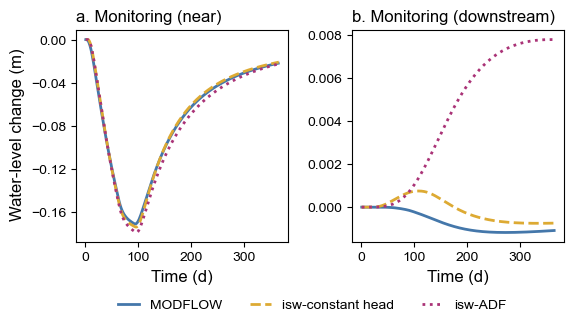

In [13]:
#| code-fold: true
#| label: fig-aquifer-drawdown
#| fig-cap: "Simulated water-level change due to pumping at (**a**) near and (**b**) downstream monitoring wells, from MODFLOW, isw-ADF, and isw-constant head. Positive indicates water-level rise, negative indicates water-level drawdown."

colors = ["#4477AA", "#DDAA33", "#AA3377"] 
linestyles = ["-", "--", ":"] 

fig, axes = plt.subplots(1, 2, figsize=(80*2*mm, 70*mm))
for ax, (name, group), color, linestyle, label in zip(axes, aquifer_depletion.groupby("observation_id", observed=True),
                                                      np.repeat(colors[0], 2), np.repeat(linestyles[0], 2),
                                                      ["MODFLOW", "MODFLOW"]):
    ax.plot(group["time"], group["water_level_change"], label=label, color=color, linestyle=linestyle, linewidth=2, zorder=0)
for ax, (name, group), color, linestyle, label in zip(np.tile(axes, 2),
                                                      aquifer_depletion_analytical.sort_values(["method", "observation_id"]).groupby(["method", "observation_id"], sort=False, observed=True),
                                                      np.repeat(colors[1:], 2), np.repeat(linestyles[1:], 2),
                                                      ["isw-constant head", "isw-constant head", "isw-ADF", "isw-ADF"]):
    ax.plot(group["time"], group["water_level_change"], label=label, color=color, linestyle=linestyle, linewidth=2, zorder=1)
for ax, title in zip(axes, ["a. Monitoring (near)", "b. Monitoring (downstream)"]):
    ax.set_title(title, fontsize=12, loc="left")
    ax.set_xlabel("Time (d)", fontsize=12)
    ax.yaxis.set_major_locator(MaxNLocator(6))
fig.supylabel("Water-level change (m)", fontsize=12)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, fontsize=10, frameon=False, handlelength=1.5, loc="upper center", bbox_to_anchor=(0.5, -0.05), ncol=3)
fig.subplots_adjust(wspace=0.3)
plt.savefig(Path("figures", "isw-modflow-aquifer-drawdown-comparison.png"), dpi=300, bbox_inches="tight", format="png")
plt.show()

#### Streamflow depletion
Similarly, there is close agreement among MODFLOW, ADF, and constant head approaches for estimating reach-scale streamflow depletion at the upstream reaches, and less agreement at the downstream reach (@fig-stream-depletion). MODFLOW and constant head estimated streamflow depletion agree closely for both upstream reaches, while ADF underestimates the magnitude of depletion. There is also less agreement at the downstream reach, as seen in the aquifer drawdown response. ADF overestimates the magnitude of streamflow depletion, while constant head predicts the opposite direction during the early part of the simulation, before converging toward the MODFLOW-estimated depletion later in the year. In addition, peak depletion timing differs among models/approaches. 

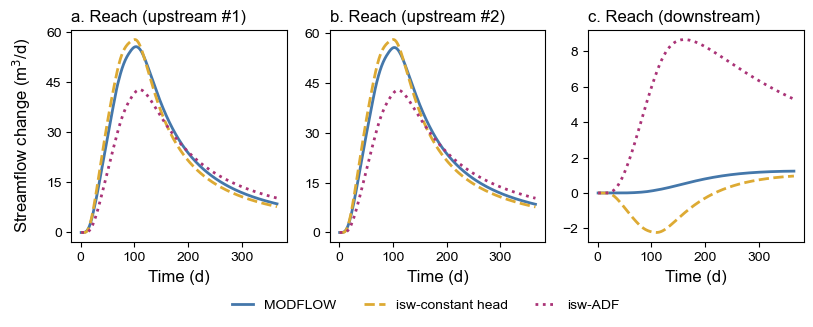

In [14]:
#| code-fold: true
#| label: fig-stream-depletion
#| fig-cap: "Simulated streamflow change due to pumping  at (**a**) upstream 1, (**b**) upstream 2, and (**c**) downstream reaches, from MODFLOW, isw-ADF, and isw-constant head. Positive indicates streamflow depletion, i.e., loss of water due to pumping."

fig, axes = plt.subplots(1, 3, figsize=(80*3*mm, 70*mm))
for ax, (name, group), color, linestyle, label in zip(axes, 
                                                      stream_depletion.groupby("reach_id", observed=True), 
                                                      np.repeat(colors[0], 3), np.repeat(linestyles[0], 3),
                                                      ["MODFLOW", "MODFLOW", "MODFLOW"]):
    ax.plot(group["time"], group["stream_depletion"], label=label, color=color, linewidth=2)
for ax, (name, group), color, linestyle, label in zip(np.tile(axes, 2), 
                                               stream_depletion_analytical.sort_values(["method", "reach_id"]).groupby(["method", "reach_id"], sort=False, observed=True),
                                               np.repeat(colors[1:], 3), np.repeat(linestyles[1:], 3),
                                               ["isw-constant head", "isw-constant head", "isw-constant head", "isw-ADF", "isw-ADF", "isw-ADF"]):
    ax.plot(group["time"], group["stream_depletion"], label=label, color=color, linestyle=linestyle, linewidth=2)
for ax, title in zip(axes, ["a. Reach (upstream #1)", "b. Reach (upstream #2)", "c. Reach (downstream)"]):
    ax.set_title(title, fontsize=12, loc="left")
    ax.set_xlabel("Time (d)", fontsize=12)
    ax.yaxis.set_major_locator(MaxNLocator(6))
fig.supylabel("Streamflow change (m$^3$/d)", fontsize=12, x=0.06)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, fontsize=10, frameon=False, handlelength=1.5, loc="upper center", bbox_to_anchor=(0.5, -0.05), ncol=3)
plt.savefig(Path("figures", "isw-modflow-stream-depletion-comparison.png"), dpi=300, bbox_inches="tight", format="png")
plt.show()

#### Thoughts
I think the main reason for the disagreement between ADF and MODFLOW/constant head approaches is due to the fact that the ADF method calculates each reach's streamflow depletion independently and does not have a mechanism to account for two upstream reaches intercepting most of the pumping signal before it reaches the downstream reach. As a result, streamflow depletion is overestimated along the downstream reach and, in turn, too much water is injected at the image-wells, leading to water level rise at the downstream monitoring well location. The constant head approach, on the other hand, does not have this issue because it solves for all three stream reach’s image-well injection rates simultaneously, effectively taking into account upstream responses. This example shows the benefits of the constant head approach in the isw package for representing complicated pumping-well, observation-well, and stream-network geometries, especially in cases where upstream reaches can alter pumping signals.

#### Additional material

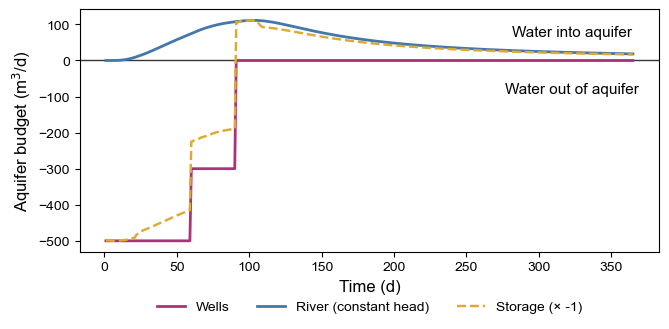

In [15]:
#| code-fold: true
#| label: fig-modflow-budget
#| fig-cap: "Simulated aquifer water budget from MODFLOW. Positive values indicate net inflow, negative values indicate net outflow. Storage is plotted with its sign reversed relative to MODFLOW convention so that negative values reflect water-level decline (release from storage) and positive values reflect water-level rise (water moving into storage)."

net_budget = compute_budget(budget, times)

fig, ax = plt.subplots(figsize=(190*mm, 80*mm))
ax.axhline(y=0, color="#373737", linewidth=1, zorder=-1)
ax.plot(net_budget["time"], net_budget["wells"], color="#AA3377", linewidth=2, label="Wells", zorder=0)
ax.plot(net_budget["time"], net_budget["constant_head"], color="#4477AA", linewidth=2, label="River (constant head)", zorder=0)
ax.plot(net_budget["time"], net_budget["storage"]*-1, color="#DDAA33", linestyle="--", linewidth=1.75, label="Storage (× -1)",zorder=0.5)
ax.text(0.85, 60, "Water into aquifer", transform=ax.get_yaxis_transform(), ha="center", va="bottom", fontsize=11)
ax.text(0.85, -60, "Water out of aquifer", transform=ax.get_yaxis_transform(), ha="center", va="top", fontsize=11)
ax.set_xlabel("Time (d)", fontsize=12)
ax.set_ylabel("Aquifer budget (m$^3$/d)", fontsize=12)
ax.legend(loc="upper center", bbox_to_anchor=(0.5,-0.15), ncols=3, frameon=False)
plt.savefig(Path("figures", "modflow-budget.png"), dpi=300, bbox_inches="tight", format="png")
plt.show()